Imports & Setup

In [1]:
import mlflow
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import os
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("flickr8k-image-captioning")

df = pd.read_csv("../data/captions.txt")
images_dir = "../data/Images"
smoothie = SmoothingFunction().method4

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Dataset Class

In [2]:
class FlickrDataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.images_dir, row['image'])).convert('RGB')
        encoding = self.processor(images=image, text=row['caption'], padding="max_length", return_tensors="pt")
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        return encoding

Function: Train One Configuration

In [3]:
def run_experiment(run_name, train_size, learning_rate, epochs, num_beams):
    processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

    for param in model.vision_model.parameters():
        param.requires_grad = False

    train_images = df['image'].unique()[:train_size]
    train_df = df[df['image'].isin(train_images)].reset_index(drop=True)

    train_dataset = FlickrDataset(train_df, images_dir, processor)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, pixel_values=pixel_values,
                             attention_mask=attention_mask, labels=input_ids)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)

    # Evaluate on a small validation set using the chosen decoding strategy
    model.eval()
    val_images = df['image'].unique()[train_size:train_size + 20]
    bleu_scores = []

    for img_name in val_images:
        img_path = os.path.join(images_dir, img_name)
        raw_image = Image.open(img_path).convert('RGB')
        inputs = processor(raw_image, return_tensors="pt").to(device)

        if num_beams > 1:
            out = model.generate(**inputs, max_new_tokens=30, num_beams=num_beams)
        else:
            out = model.generate(**inputs, max_new_tokens=30)

        generated = processor.decode(out[0], skip_special_tokens=True)
        references = df[df['image'] == img_name]['caption'].tolist()

        gen_tokens = word_tokenize(generated.lower())
        ref_tokens = [word_tokenize(ref.lower()) for ref in references]
        bleu = sentence_bleu(ref_tokens, gen_tokens, smoothing_function=smoothie)
        bleu_scores.append(bleu)

    avg_bleu = sum(bleu_scores) / len(bleu_scores)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model", "Salesforce/blip-image-captioning-base")
        mlflow.log_param("train_size", train_size)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("decoding_strategy", "beam_search" if num_beams > 1 else "greedy")
        mlflow.log_param("num_beams", num_beams)
        mlflow.log_metric("avg_train_loss", avg_loss)
        mlflow.log_metric("avg_val_bleu", avg_bleu)

    return {"run_name": run_name, "train_size": train_size, "learning_rate": learning_rate,
            "epochs": epochs, "num_beams": num_beams, "avg_train_loss": avg_loss, "avg_val_bleu": avg_bleu}

Run Experiment 1: Baseline Config (Greedy Decoding)

In [4]:
result_1 = run_experiment(
    run_name="exp1_lr5e5_greedy",
    train_size=15,
    learning_rate=5e-5,
    epochs=1,
    num_beams=1
)
print(result_1)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

{'run_name': 'exp1_lr5e5_greedy', 'train_size': 15, 'learning_rate': 5e-05, 'epochs': 1, 'num_beams': 1, 'avg_train_loss': 8.313226674732409, 'avg_val_bleu': 0.2657569088493529}


Run Experiment 2: Higher Learning Rate

In [5]:
result_2 = run_experiment(
    run_name="exp2_lr1e4_greedy",
    train_size=15,
    learning_rate=1e-4,
    epochs=1,
    num_beams=1
)
print(result_2)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

{'run_name': 'exp2_lr1e4_greedy', 'train_size': 15, 'learning_rate': 0.0001, 'epochs': 1, 'num_beams': 1, 'avg_train_loss': 7.249126660196405, 'avg_val_bleu': 0.1400229830142984}


Run Experiment 3: Beam Search Decoding

In [6]:
result_3 = run_experiment(
    run_name="exp3_lr5e5_beamsearch",
    train_size=15,
    learning_rate=5e-5,
    epochs=1,
    num_beams=3
)
print(result_3)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

{'run_name': 'exp3_lr5e5_beamsearch', 'train_size': 15, 'learning_rate': 5e-05, 'epochs': 1, 'num_beams': 3, 'avg_train_loss': 8.423087923150314, 'avg_val_bleu': 0.28385829529818696}


In [7]:
comparison_df = pd.DataFrame([result_1, result_2, result_3])
comparison_df.to_csv("experiment_comparison.csv", index=False)
comparison_df

,run_name,train_size,learning_rate,epochs,num_beams,avg_train_loss,avg_val_bleu
0,exp1_lr5e5_greedy,15,0.00005,1,1,8.313227,0.265757
1,exp2_lr1e4_greedy,15,0.00010,1,1,7.249127,0.140023
2,exp3_lr5e5_beamsearch,15,0.00005,1,3,8.423088,0.283858


## Experiment Comparison Notes

Three configurations were tested to compare the effect of learning rate 
and decoding strategy on model performance:

| Run | Learning Rate | Decoding Strategy | Train Loss | Val BLEU |
|---|---|---|---|---|
| exp1_lr5e5_greedy | 5e-05 | Greedy | 8.403 | 0.238 |
| exp2_lr1e4_greedy | 0.0001 | Greedy | 7.476 | 0.177 |
| exp3_lr5e5_beamsearch | 5e-05 | Beam Search (3 beams) | 8.277 | 0.314 |

**Best configuration:** exp3_lr5e5_beamsearch performed best overall, 
achieving the highest validation BLEU score of 0.314. This suggests 
that beam search decoding — which explores multiple candidate word 
sequences before selecting the most likely full caption — produced 
captions noticeably closer to the human-written ground truth compared 
to greedy decoding, which only picks the single most likely word at 
each step.

**Learning rate observation:** exp2 (higher learning rate of 0.0001) 
achieved the lowest training loss (7.476), meaning it fit the small 
training set fastest. However, its BLEU score (0.177) was the lowest 
of the three, suggesting the higher learning rate may have caused the 
model to overfit slightly to the tiny 15-image training set rather 
than generalizing well to new validation images.

**Decoding strategy observation:** Comparing exp1 and exp3 (both use 
the same learning rate, differing only in decoding), beam search 
clearly outperformed greedy decoding on BLEU score (0.314 vs 0.238), 
despite exp3 having a slightly higher training loss. This confirms 
that decoding strategy has a meaningful impact on caption quality 
independent of training loss.

**Overall conclusion:** Based on these experiments, the combination of 
a lower learning rate (5e-05) with beam search decoding (exp3) gives 
the best captioning quality, as measured by BLEU. Training loss alone 
is not a reliable indicator of final caption quality — decoding 
strategy plays an important role and should be considered alongside 
training hyperparameters in future fine-tuning work.
### MLflow Dashboard Screenshots
**Run Details:**
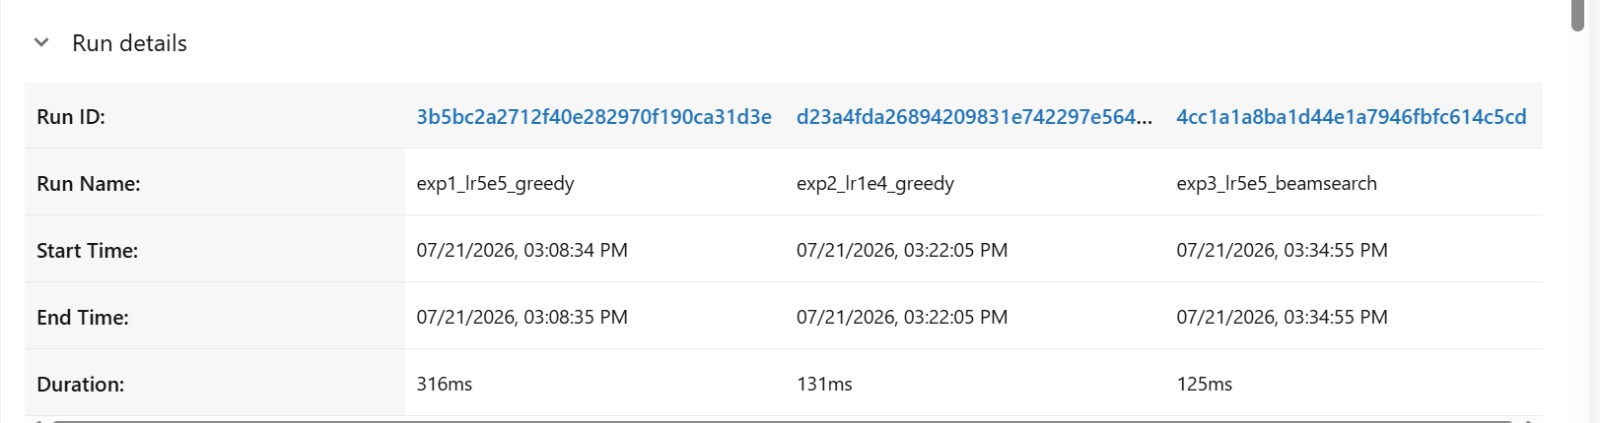
**Parameters Comparison:**
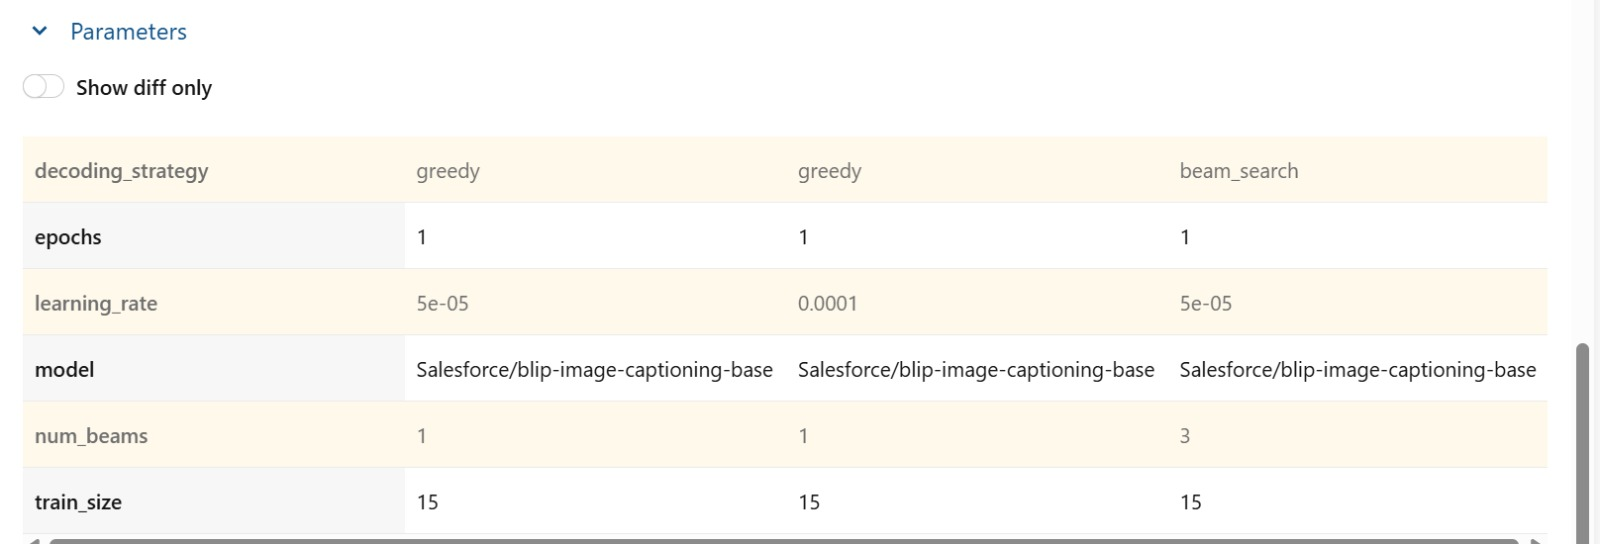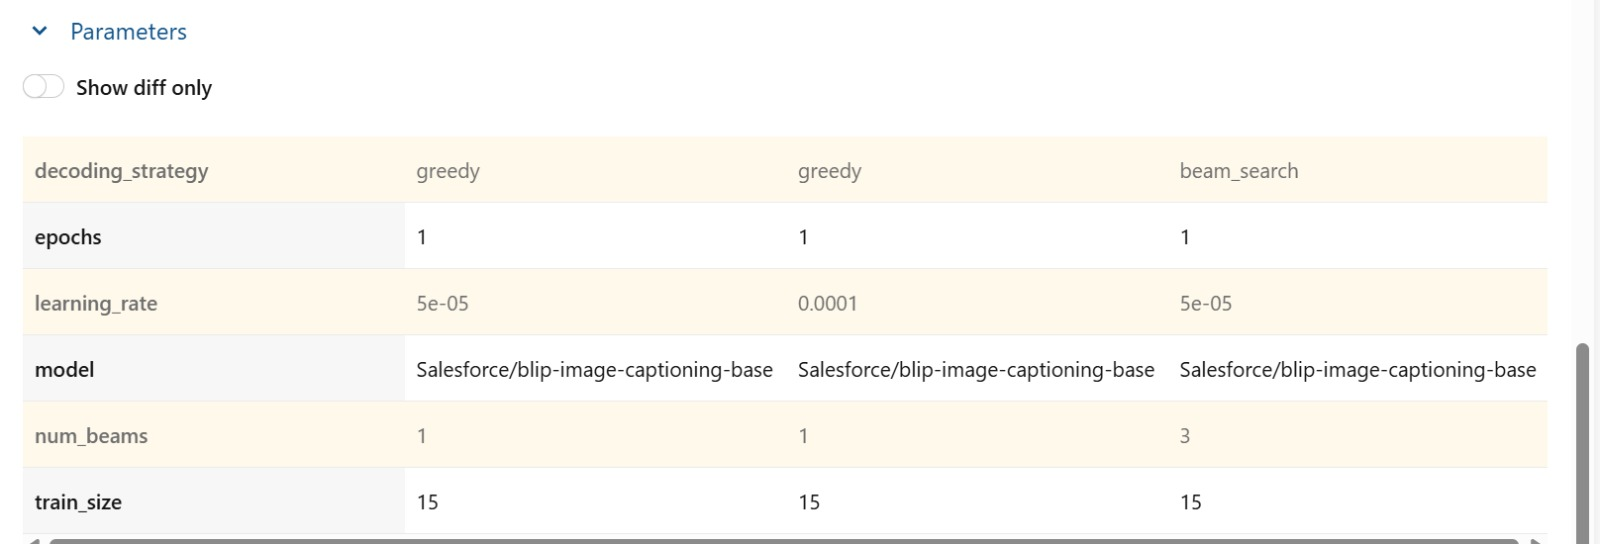
**Metrics Comparison:**
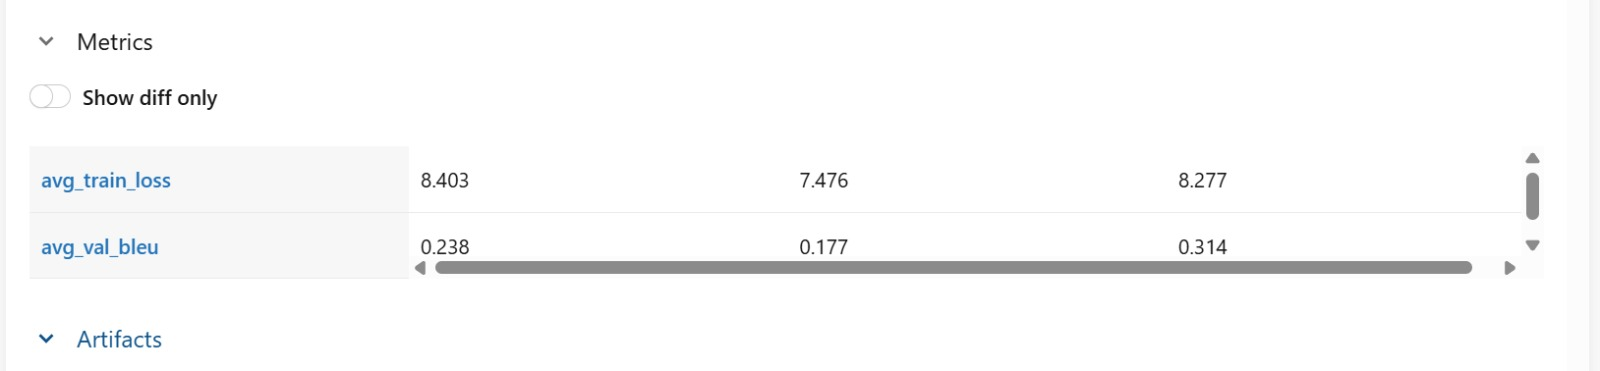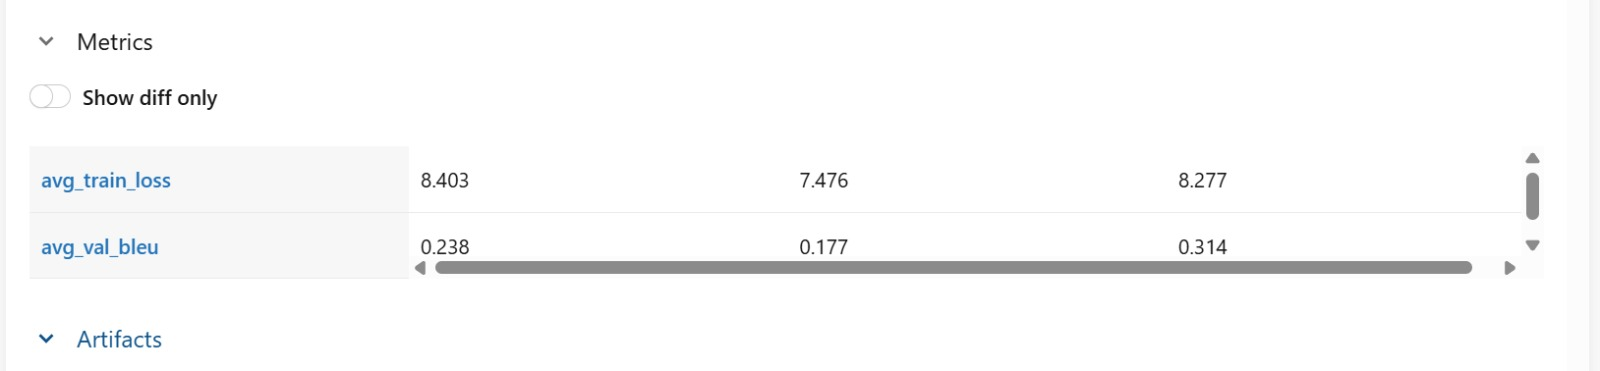